# Chapter 12 — Randomized numerical linear algebra

**Numerical Linear Algebra: Theory, Algorithms, and Computation**

**Abdallah Alsammani, Ph.D.**  
Department of Mathematical Sciences & Data Science  
Delaware State University

Lecture notes: <https://aalsammani.github.io/numerical-linear-algebra/>  
Notes for this chapter: <https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html>  
Repository: <https://github.com/aalsammani/Numerical-Linear-Algebra-Notebooks>

This notebook is the computational laboratory of the chapter; the theory,
proofs and exercises are in the lecture notes, to which the links below
point. References such as Trefethen and Bau (1997) are listed in the
[bibliography of the notes](https://aalsammani.github.io/numerical-linear-algebra/back/bibliography.html). Version
1.0, September 2026.

---

This notebook accompanies [Chapter 12](https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html#ch12) of the notes. It
implements the randomized range finder and the randomized SVD from scratch,
tests them against the optimal (Eckart--Young) errors computed with the full
SVD, applies them to a photograph, and then turns to random embeddings and
randomized least-squares solvers.

**Learning objectives.** After working through this lab you should be able to

1. implement the Gaussian range finder, the randomized SVD and randomized
   subspace iteration using a `numpy.random.Generator`, and verify them with
   assertions derived from the theory;
2. measure how the error depends on the target rank, the oversampling
   parameter and the number of power iterations, relative to the optimal
   error, for matrices with fast, slow and step-like singular value decay;
3. explain why the power scheme must re-orthonormalize between products;
4. estimate the approximation error a posteriori from a few extra samples;
5. observe the Johnson--Lindenstrauss phenomenon for a finite point set;
6. compare sketch-and-solve and sketch-and-precondition with a direct
   least-squares solver, and measure the condition number of $AR^{-1}$.

Run the cells in order from a fresh kernel. Randomized algorithms return
different results for different seeds; all numbers printed below are for the
seed fixed in the setup cell, and all timings are observations on the machine
that executed the notebook.

In [1]:
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as sla
from scipy.sparse.linalg import LinearOperator, lsqr
from scipy.spatial.distance import pdist

rng = np.random.default_rng(20260927)
u = np.finfo(float).eps / 2          # unit roundoff of IEEE double precision, 2**-53
plt.rcParams.update({"figure.figsize": (6.4, 4.0), "axes.grid": True, "grid.alpha": 0.3})

DATA_URL = "https://raw.githubusercontent.com/aalsammani/Numerical-Linear-Algebra-Notebooks/main/data/"


def data_file(name):
    """Return a path to data/<name>, downloading it if it is not available locally."""
    local = Path("data") / name
    if local.exists():
        return local
    target = Path(name)
    if not target.exists():
        urllib.request.urlretrieve(DATA_URL + name, target)
    return target


def median_time(f, repeats=7):
    """Median wall-clock time of f() over several repeats, after one warm-up call."""
    f()
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        f()
        times.append(time.perf_counter() - t0)
    return float(np.median(times))


print(f"NumPy {np.__version__}; unit roundoff u = {u:.3e}")

NumPy 2.5.3; unit roundoff u = 1.110e-16


## 1. Test matrices with prescribed singular values

To compare a randomized approximation with the best possible one we need
matrices whose singular values we know exactly. We form
$A = U\operatorname{diag}(\sigma)V^T$ with random orthogonal $U$ and $V$,
obtained from the QR factorization of Gaussian matrices (with the signs of
$R$'s diagonal moved into $Q$, which makes the distribution uniform on the
orthogonal group). The computed $A$ has singular values equal to $\sigma_j$ up to
absolute errors of order $n u \sigma_1$.

We use three spectra of order $n = 400$:

- **fast** exponential decay, $\sigma_j = e^{-(j-1)/8}$;
- **slow** polynomial decay, $\sigma_j = 1/j$;
- **step**: $\sigma_j = 1$ for $j\le 15$ and $\sigma_j = 10^{-2}$ afterwards,
  a matrix of numerical rank 15 plus a flat "noise floor".

fast : max |sigma_j(computed) - sigma_j| = 6.7e-16
slow : max |sigma_j(computed) - sigma_j| = 2.8e-16
step : max |sigma_j(computed) - sigma_j| = 4.8e-16


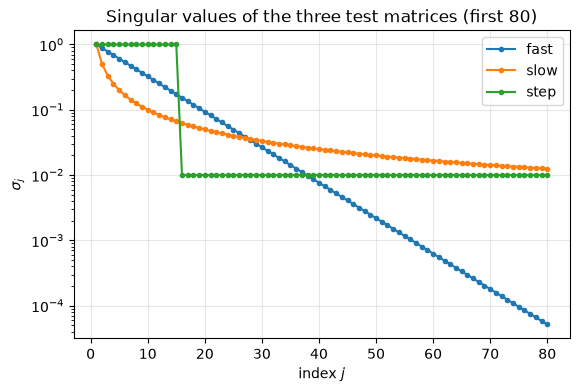

In [2]:
def haar_orthogonal(n, rng):
    """Random orthogonal matrix (Haar distributed) from the QR factorization of a Gaussian matrix."""
    Q, R = np.linalg.qr(rng.standard_normal((n, n)))
    return Q * np.sign(np.diag(R))


def matrix_with_singular_values(sigma, rng, m=None):
    """Return A = U diag(sigma) V^T of size m x n (n = len(sigma), m >= n) with random orthogonal factors."""
    n = sigma.size
    m = n if m is None else m
    U = haar_orthogonal(m, rng)[:, :n]
    V = haar_orthogonal(n, rng)
    return (U * sigma) @ V.T


n = 400
j = np.arange(1, n + 1)
spectra = {
    "fast": np.exp(-(j - 1) / 8.0),
    "slow": 1.0 / j,
    "step": np.where(j <= 15, 1.0, 1e-2),
}
mats = {name: matrix_with_singular_values(s, rng) for name, s in spectra.items()}

for name, A in mats.items():
    s_computed = np.linalg.svd(A, compute_uv=False)
    err = np.max(np.abs(s_computed - spectra[name]))
    print(f"{name:5s}: max |sigma_j(computed) - sigma_j| = {err:.1e}")
    assert err < 10 * n * u * spectra[name][0]      # backward stable SVD: absolute errors O(n u sigma_1)

fig, ax = plt.subplots()
for name, s in spectra.items():
    ax.semilogy(j[:80], s[:80], ".-", label=name)
ax.set_xlabel("index $j$")
ax.set_ylabel(r"$\sigma_j$")
ax.set_title("Singular values of the three test matrices (first 80)")
ax.legend()
plt.show()

## 2. The randomized range finder and the randomized SVD

The range finder draws a Gaussian test matrix $\Omega\in\mathbb{R}^{n\times\ell}$,
$\ell = k+p$, forms $Y = A\Omega$ and orthonormalizes it. With $q>0$ it
performs $q$ steps of subspace iteration with $A A^T$, re-orthonormalizing
after **every** product with $A$ or $A^T$. The randomized SVD then computes
the SVD of the small matrix $B = Q^TA$ and truncates it to rank $k$.

We only ever touch $A$ through products `A @ X` and `A.T @ X`, so the same
code works for any object that supports them.

In [3]:
def range_finder(A, ell, q=0, rng=None):
    """Orthonormal Q (m x ell) whose range approximates the dominant range of A.

    Gaussian test matrix, followed by q steps of subspace iteration with
    re-orthonormalization after every product (randomized subspace iteration).
    """
    rng = np.random.default_rng() if rng is None else rng
    Omega = rng.standard_normal((A.shape[1], ell))
    Q, _ = np.linalg.qr(A @ Omega)
    for _ in range(q):
        W, _ = np.linalg.qr(A.T @ Q)
        Q, _ = np.linalg.qr(A @ W)
    return Q


def randomized_svd(A, k, p=10, q=0, rng=None):
    """Rank-k approximation U diag(s) Vt of A from the range finder with ell = k + p columns."""
    Q = range_finder(A, k + p, q, rng)
    B = Q.T @ A                                   # ell x n, a second pass over A
    Ub, s, Vt = np.linalg.svd(B, full_matrices=False)
    U = Q @ Ub[:, :k]
    return U, s[:k], Vt[:k]


def optimal_errors(sigma, k):
    """Eckart-Young: the smallest possible rank-k errors in the 2-norm and the Frobenius norm."""
    return sigma[k], np.sqrt(np.sum(sigma[k:] ** 2))

**Verification 1: exact recovery of low-rank matrices.** If
$\operatorname{rank}(A) = r \le \ell$, then with probability one
$\operatorname{range}(A\Omega) = \operatorname{range}(A)$ and $A = QQ^TA$ exactly
([Proposition 12.2](https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html#ch12-prop-exact-rank)). In floating point, the computed $Y$
differs from $A\Omega$ by rounding errors of relative size about $nu$, and
a perturbation of that size tilts the computed range by an angle of order
$nu\,\|A\|_2\|\Omega\|_2/\sigma_r(A\Omega)$. For our matrix the nonzero singular
values lie in $[0.1, 1]$ and $\Omega$ is a well-conditioned Gaussian matrix,
so we expect $\|A - QQ^TA\|_2/\|A\|_2$ to be a modest multiple of $nu$. We
test against $10^3\,nu$, which leaves room for the factor
$\sigma_1(A)/\sigma_r(A) = 10$ and for $\|\Omega\|_2/\sigma_{\min}(V_r^T\Omega)$.

In [4]:
m, n_small, r = 500, 300, 15
sigma_r = np.concatenate([np.linspace(1.0, 0.1, r), np.zeros(n_small - r)])
A_low = matrix_with_singular_values(sigma_r, rng, m=m)

for ell in (r, r + 5, r + 20):
    Q = range_finder(A_low, ell, rng=rng)
    rel = np.linalg.norm(A_low - Q @ (Q.T @ A_low), 2) / np.linalg.norm(A_low, 2)
    orth = np.linalg.norm(Q.T @ Q - np.eye(ell), 2)
    print(f"ell = {ell:2d}: ||A - QQ^T A||_2 / ||A||_2 = {rel:.1e}   ||Q^T Q - I||_2 = {orth:.1e}   (n u = {n_small * u:.1e})")
    assert orth < 10 * m * u                        # Householder QR: orthogonality O(m u)
    assert rel < 1e3 * n_small * u                  # exact in exact arithmetic when ell >= rank

ell = 15: ||A - QQ^T A||_2 / ||A||_2 = 7.6e-15   ||Q^T Q - I||_2 = 9.1e-16   (n u = 3.3e-14)
ell = 20: ||A - QQ^T A||_2 / ||A||_2 = 1.9e-15   ||Q^T Q - I||_2 = 9.2e-16   (n u = 3.3e-14)
ell = 35: ||A - QQ^T A||_2 / ||A||_2 = 6.2e-16   ||Q^T Q - I||_2 = 1.2e-15   (n u = 3.3e-14)


Even $\ell = r$ (no oversampling) recovers a rank-$r$ matrix: the $r\times r$
Gaussian matrix $V_r^T\Omega$ is invertible with probability one. Oversampling
matters only when $A$ is not exactly of low rank.

**Verification 2: the randomized SVD against the full SVD.** Three facts
must hold for every draw of $\Omega$: the computed $U$ has orthonormal columns
to working accuracy; with $k = \ell$ (no truncation) the error of the
randomized SVD equals $\|(I - QQ^T)A\|$; and no rank-$k$ approximation can beat
the Eckart--Young error $\sigma_{k+1}$ (the error of the truncated SVD from
`np.linalg.svd`).

In [5]:
A = mats["slow"]
sigma = spectra["slow"]
k, p = 20, 10

U, s, Vt = randomized_svd(A, k, p, rng=rng)
A_k_rand = (U * s) @ Vt
Uf, sf, Vtf = np.linalg.svd(A)
A_k_opt = (Uf[:, :k] * sf[:k]) @ Vtf[:k]

err_rand = np.linalg.norm(A - A_k_rand, 2)
err_opt = np.linalg.norm(A - A_k_opt, 2)
print(f"||U^T U - I||_2          = {np.linalg.norm(U.T @ U - np.eye(k), 2):.1e}")
print(f"optimal error sigma_k+1  = {sigma[k]:.6f}; truncated np.linalg.svd gives {err_opt:.6f}")
print(f"randomized SVD error     = {err_rand:.6f}  (ratio {err_rand / sigma[k]:.3f})")
print(f"leading singular values: exact {sigma[:3].round(6)}, randomized {s[:3].round(6)}")
assert np.linalg.norm(U.T @ U - np.eye(k), 2) < 10 * n * u
assert abs(err_opt - sigma[k]) < 10 * n * u         # Eckart-Young, up to rounding in the SVD
assert err_rand >= sigma[k] * (1 - 10 * n * u)      # nothing beats the truncated SVD

# Without truncation the randomized SVD is exactly Q Q^T A (up to rounding).
Q = range_finder(A, k + p, rng=rng)
Ub, sb, Vtb = np.linalg.svd(Q.T @ A, full_matrices=False)
diff = np.linalg.norm((Q @ Ub) * sb @ Vtb - Q @ (Q.T @ A), 2)
print(f"||Q (SVD of B) - Q Q^T A||_2 = {diff:.1e}")
assert diff < 10 * n * u * np.linalg.norm(A, 2)

||U^T U - I||_2          = 2.5e-15
optimal error sigma_k+1  = 0.047619; truncated np.linalg.svd gives 0.047619
randomized SVD error     = 0.078358  (ratio 1.646)
leading singular values: exact [1.       0.5      0.333333], randomized [0.999251 0.497619 0.331431]
||Q (SVD of B) - Q Q^T A||_2 = 4.7e-15


The randomized singular values are smaller than the exact ones, as they
must be: $\sigma_j(Q^TA)\le\sigma_j(A)$ for every $j$ because $\|Q^T\|_2 = 1$
([Proposition 12.3](https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html#ch12-prop-rsvd-truncation)).

## 3. Error as a function of the target rank

For each spectrum and each $k$ we compare the rank-$k$ randomized SVD
($p = 5$, $q = 0$) with the optimal error, in both norms. A ratio of $1$ means
the randomized method is as good as the truncated SVD.

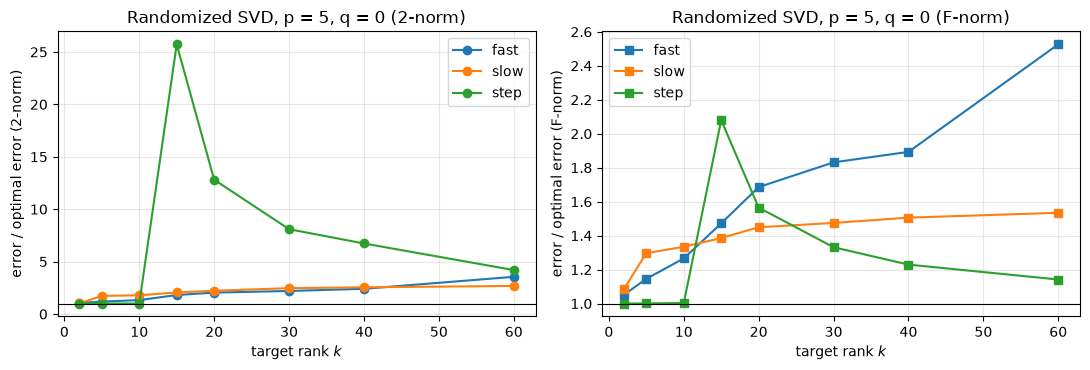

fast : 2-norm ratios [1.05 1.18 1.33 1.81 2.04 2.2  2.4  3.55]
       F-norm ratios [1.05 1.15 1.27 1.47 1.69 1.83 1.89 2.53]
slow : 2-norm ratios [1.01 1.73 1.79 2.05 2.22 2.47 2.55 2.68]
       F-norm ratios [1.09 1.3  1.33 1.39 1.45 1.47 1.51 1.53]
step : 2-norm ratios [ 1.    1.    1.   25.73 12.81  8.09  6.73  4.19]
       F-norm ratios [1.   1.   1.   2.08 1.57 1.33 1.23 1.14]


In [6]:
ks = [2, 5, 10, 15, 20, 30, 40, 60]
p, trials = 5, 5
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
summary = {}
for name, A in mats.items():
    sigma = spectra[name]
    r2, rF = [], []
    for k in ks:
        e2, eF = [], []
        for _ in range(trials):
            U, s, Vt = randomized_svd(A, k, p, rng=rng)
            E = A - (U * s) @ Vt
            e2.append(np.linalg.norm(E, 2))
            eF.append(np.linalg.norm(E, "fro"))
        opt2, optF = optimal_errors(sigma, k)
        r2.append(np.mean(e2) / opt2)
        rF.append(np.mean(eF) / optF)
        assert min(e2) >= opt2 * (1 - 1e-12) and min(eF) >= optF * (1 - 1e-12)   # Eckart-Young
    summary[name] = (r2, rF)
    axes[0].plot(ks, r2, "o-", label=name)
    axes[1].plot(ks, rF, "s-", label=name)
for ax, norm in zip(axes, ("2", "F")):
    ax.axhline(1, color="k", lw=0.8)
    ax.set_xlabel("target rank $k$")
    ax.set_ylabel(f"error / optimal error ({norm}-norm)")
    ax.set_title(f"Randomized SVD, p = {p}, q = 0 ({norm}-norm)")
    ax.legend()
plt.tight_layout()
plt.show()
for name, (r2, rF) in summary.items():
    print(f"{name:5s}: 2-norm ratios {np.round(r2, 2)}")
    print(f"{'':5s}  F-norm ratios {np.round(rF, 2)}")

**Interpretation.** In the Frobenius norm the ratio stays modest for all three
matrices, in line with the expected-error bounds of
[Theorem 12.5](https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html#ch12-thm-frobenius-bound) and [Proposition 12.3](https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html#ch12-prop-rsvd-truncation)
(for $p = 5$ they give at most $(2 + k/4)^{1/2}$ for the truncated
approximation). In the 2-norm the picture depends on the spectrum and on $k$.
With $p$ fixed, the factor $1 + \sqrt{k/(p-1)}$ in
[(12.7)](https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html#equation-ch12-eq-spectral-bound) grows with $k$, and so do the observed ratios
for the fast and slow spectra. For the step matrix, the ratio is 1 for
$k\le 10$: then $\sigma_{k+1} = 1$ belongs to the flat top of the spectrum,
and the samples capture the top 15 directions well enough that the rank-$k$
truncation is optimal. For $k = 15$ it jumps: the tail
$(\sum_{j>k}\sigma_j^2)^{1/2}\approx 0.2$ is twenty times $\sigma_{k+1} = 0.01$, and
the random samples cannot distinguish the flat "noise" directions from each
other. This is the second term of the spectral-norm bound
[(12.7)](https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html#equation-ch12-eq-spectral-bound), and it is what power iterations fix
(Section 5).

## 4. The effect of oversampling

[Theorem 12.5](https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html#ch12-thm-frobenius-bound) bounds the *expected* Frobenius error of
the rank-$\ell$ approximation $QQ^TA$, $\ell = k+p$, by
$\sqrt{1 + k/(p-1)}$ times the optimal rank-$k$ error. We estimate the
expectation by averaging over trials.

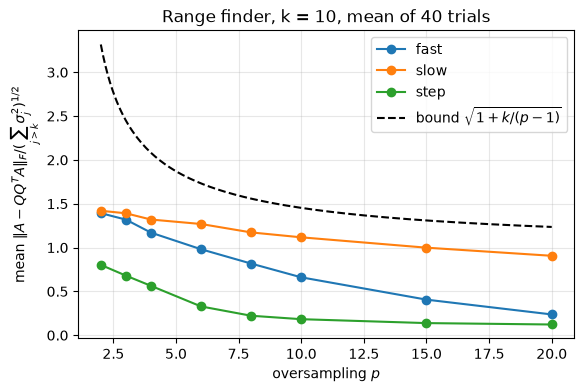

In [7]:
k, trials = 10, 40
ps = [2, 3, 4, 6, 8, 10, 15, 20]
fig, ax = plt.subplots()
for name, A in mats.items():
    tail = optimal_errors(spectra[name], k)[1]
    means = []
    for p in ps:
        errs = []
        for _ in range(trials):
            Q = range_finder(A, k + p, rng=rng)
            errs.append(np.linalg.norm(A - Q @ (Q.T @ A), "fro") / tail)
        means.append(np.mean(errs))
        # The theorem bounds the expectation, not a sample mean. The sample mean of 40 trials
        # fluctuates around the expectation by a few percent, so we allow a 20 percent margin.
        assert np.mean(errs) <= 1.2 * np.sqrt(1 + k / (p - 1))
    ax.plot(ps, means, "o-", label=name)
pp = np.linspace(2, 20, 200)
ax.plot(pp, np.sqrt(1 + k / (pp - 1)), "k--", label=r"bound $\sqrt{1 + k/(p-1)}$")
ax.set_xlabel("oversampling $p$")
ax.set_ylabel(r"mean $\|A - QQ^TA\|_F / (\sum_{j>k}\sigma_j^2)^{1/2}$")
ax.set_title(f"Range finder, k = {k}, mean of {trials} trials")
ax.legend()
plt.show()

All curves lie below the bound, and for the fast and step spectra the ratio
drops well below 1: a rank-$(k+p)$ approximation can of course be better than
the best rank-$k$ one. The slow spectrum is the hardest case for the
range finder, and for it the bound exceeds the observed mean only by a small
factor. The practical rule that emerges, $p = 5$ to $10$, costs little
because the work grows only linearly in $\ell$.

## 5. Power iterations and the need to re-orthonormalize

For slowly decaying spectra the range finder is applied to $(AA^T)^qA$,
whose singular values are $\sigma_j^{2q+1}$. We compare two
implementations: `range_finder` above, which re-orthonormalizes after
every product, and a naive version that forms $(AA^T)^qA\Omega$ and
orthonormalizes once at the end.

slow: 2-norm error / sigma_(k+1) for q = 0..6: [1.679 1.006 1.    1.    1.    1.    1.   ]


step: 2-norm error / sigma_(k+1) for q = 0..6: [27.096  1.     1.     1.     1.     1.     1.   ]


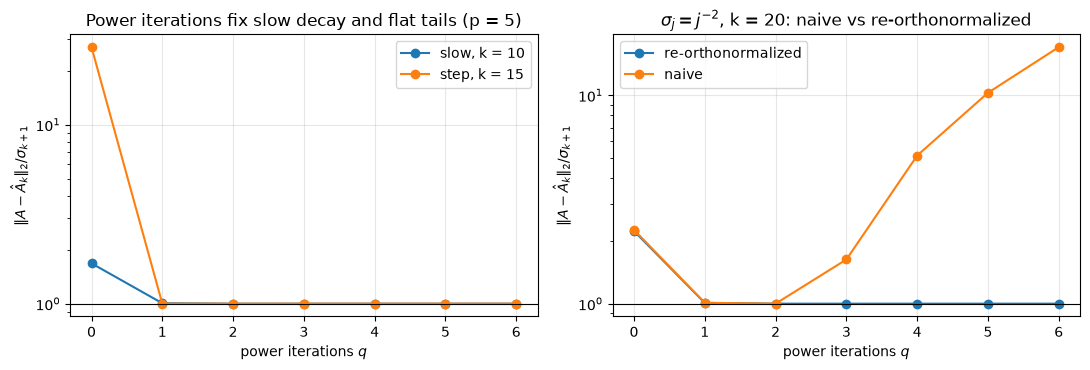

re-orthonormalized: [2.231 1.008 1.    1.    1.    1.    1.   ]
naive             : [ 2.259  1.01   1.     1.629  5.136 10.276 17.012]
threshold u^(1/(2q+1)) for q = 0..6: 1.1e-16 4.8e-06 6.4e-04 5.3e-03 1.7e-02 3.5e-02 5.9e-02
sigma_(k+1)/sigma_1 = 2.27e-03


In [8]:
def range_finder_naive(A, ell, q=0, rng=None):
    """Power scheme WITHOUT intermediate orthonormalization (numerically unsafe)."""
    Y = A @ rng.standard_normal((A.shape[1], ell))
    for _ in range(q):
        Y = A @ (A.T @ Y)
    Q, _ = np.linalg.qr(Y)
    return Q


def rsvd_error_from_basis(A, Q, k):
    Ub, s, Vt = np.linalg.svd(Q.T @ A, full_matrices=False)
    return np.linalg.norm(A - (Q @ Ub[:, :k]) * s[:k] @ Vt[:k], 2)


qs = range(0, 7)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
p = 5
for name, k in (("slow", 10), ("step", 15)):              # the two hard cases of Section 3
    A, sigma = mats[name], spectra[name]
    ratios = [np.mean([rsvd_error_from_basis(A, range_finder(A, k + p, q, rng), k) for _ in range(3)]) / sigma[k]
              for q in qs]
    axes[0].plot(list(qs), ratios, "o-", label=f"{name}, k = {k}")
    print(f"{name}: 2-norm error / sigma_(k+1) for q = 0..6: {np.round(ratios, 3)}")
k = 20
sigma2 = 1.0 / j**2
A2 = matrix_with_singular_values(sigma2, rng)
res = {}
for f, label in [(range_finder, "re-orthonormalized"), (range_finder_naive, "naive")]:
    res[label] = [np.mean([rsvd_error_from_basis(A2, f(A2, k + p, q, rng), k) for _ in range(3)]) / sigma2[k]
                  for q in qs]
    axes[1].semilogy(list(qs), res[label], "o-", label=label)
for ax in axes:
    ax.axhline(1, color="k", lw=0.8)
    ax.set_xlabel("power iterations $q$")
    ax.set_ylabel(r"$\|A - \hat A_k\|_2 / \sigma_{k+1}$")
axes[0].set_yscale("log")
axes[0].set_title("Power iterations fix slow decay and flat tails (p = 5)")
axes[1].set_title(r"$\sigma_j = j^{-2}$, k = 20: naive vs re-orthonormalized")
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()
for label, r in res.items():
    print(f"{label:18s}: {np.round(r, 3)}")
print("threshold u^(1/(2q+1)) for q = 0..6:", " ".join(f"{u ** (1 / (2 * q + 1)):.1e}" for q in qs))
print(f"sigma_(k+1)/sigma_1 = {sigma2[k]:.2e}")
assert res["re-orthonormalized"][-1] < 1.05           # near-optimal after a few stable iterations
assert res["naive"][-1] > 2                             # the naive scheme has lost the small directions

**Interpretation.** Left: for the two hard cases of Section 3 (the slow
spectrum with $k = 10$ and the step spectrum with $k = 15$), one or two power
iterations bring the spectral-norm error to within a few percent of optimal.
Right: the
naive version is just as good for $q\le2$, but for $q\ge3$ it deteriorates.
In floating point, the columns of $(AA^T)^qA\Omega$ carry the component
along the $j$th singular vector with weight $\sigma_j^{2q+1}$; once
$\sigma_j^{2q+1}/\sigma_1^{2q+1}$ falls below about $u$, that component is lost in
rounding errors of the dominant ones. The printed thresholds
$u^{1/(2q+1)}$ exceed $\sigma_{21}/\sigma_1 = 1/441$ from $q = 3$ on, exactly
where the naive curve breaks away. Orthonormalizing after every product keeps
all directions at unit scale and avoids the problem.

## 6. A posteriori error estimation

The theory gives expected errors in terms of singular values that we do not
know. In practice we *measure* the error with a few extra Gaussian vectors:
for Gaussian $\omega$, $\mathbb{E}\|(I - QQ^T)A\omega\|_2^2 = \|(I-QQ^T)A\|_F^2$
([Proposition 12.4](https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html#ch12-prop-error-estimator)). The next cell compares the estimate
from $r = 10$ probes with the true error.

In [9]:
A, sigma = mats["slow"], spectra["slow"]
r_probe = 10
print(" ell   true ||(I-QQ^T)A||_F   estimate   ratio")
for ell in (10, 20, 40, 80):
    Q = range_finder(A, ell, rng=rng)
    true_F = np.linalg.norm(A - Q @ (Q.T @ A), "fro")
    W = A @ rng.standard_normal((n, r_probe))
    W -= Q @ (Q.T @ W)
    est_F = np.sqrt(np.sum(W**2) / r_probe)
    print(f"{ell:4d}   {true_F:20.4f}   {est_F:8.4f}   {est_F / true_F:5.2f}")

 ell   true ||(I-QQ^T)A||_F   estimate   ratio
  10                 0.4697     0.5408    1.15
  20                 0.3386     0.3378    1.00
  40                 0.2332     0.2350    1.01
  80                 0.1596     0.1675    1.05


With ten probes the estimate is within a few percent of the true error here;
in general its relative fluctuation is of order $\sqrt{2/r}$ or smaller, which
is enough to decide whether to enlarge $\ell$. The **adaptive range
finder** below uses this idea: it adds blocks of $b$ new samples until the
estimated error, computed from the newest block *before* it is added to the
basis, is below a tolerance.

In [10]:
def adaptive_range_finder(A, tol, block=10, max_cols=None, rng=None):
    """Grow Q in blocks until the Frobenius error estimate from a fresh block is <= tol."""
    m, n = A.shape
    max_cols = min(m, n) if max_cols is None else max_cols
    Q = np.zeros((m, 0))
    while Q.shape[1] < max_cols:
        Y = A @ rng.standard_normal((n, block))
        Y -= Q @ (Q.T @ Y)                        # residual samples (I - QQ^T) A Omega
        est = np.sqrt(np.sum(Y**2) / block)       # estimates ||(I - QQ^T)A||_F for the current Q
        if est <= tol:
            break
        Y -= Q @ (Q.T @ Y)                        # second Gram-Schmidt pass for orthogonality
        Qnew, _ = np.linalg.qr(Y)
        Q = np.hstack([Q, Qnew])
    return Q, est


for tol in (0.5, 0.2, 0.1):
    Q, est = adaptive_range_finder(mats["slow"], tol, rng=rng)
    true_F = np.linalg.norm(mats["slow"] - Q @ (Q.T @ mats["slow"]), "fro")
    k_needed = int(np.argmax(np.sqrt(np.cumsum(spectra["slow"][::-1] ** 2))[::-1] <= tol))
    print(f"tol = {tol}: {Q.shape[1]:3d} columns, last estimate {est:.3f}, true error {true_F:.3f}, "
          f"optimal rank for this tolerance {k_needed}")
    assert np.linalg.norm(Q.T @ Q - np.eye(Q.shape[1]), 2) < 10 * n * u

tol = 0.5:  20 columns, last estimate 0.386, true error 0.353, optimal rank for this tolerance 4
tol = 0.2:  60 columns, last estimate 0.185, true error 0.187, optimal rank for this tolerance 24
tol = 0.1: 160 columns, last estimate 0.097, true error 0.100, optimal rank for this tolerance 80


The estimates track the true errors closely, but the adaptive scheme stops
with two to five times as many columns as the optimal rank: for this slowly
decaying spectrum, a range finder without power iterations needs many more
samples than the optimal rank to reach a given error (compare Section 3), and
columns are added in blocks of ten ([Exercise 12.11](https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html#ch12-ex-adaptive)).

## 7. Application: the "ascent" photograph

The file `data/ascent.npz` contains the $512\times512$ 8-bit grayscale image
distributed by SciPy as `scipy.datasets.ascent()` (key `image`, gray levels 0
to 255). The SciPy documentation states that it is derived from a
photograph released under CC0 (public domain) on [pixnio.com](https://pixnio.com/people/accent-to-the-top); see
`data/README.md` for the source and checksum. We treat it as a matrix and
compare rank-$k$ approximations from the full SVD and from the randomized SVD.

image shape (512, 512) gray levels 0.0 to 255.0
sigma_1 = 45559.5, sigma_51 = 999.3, relative optimal Frobenius error at k = 50: 0.1243


q = 0: 2-norm error / optimal = 1.996, Frobenius error / optimal = 1.430
q = 1: 2-norm error / optimal = 1.128, Frobenius error / optimal = 1.030
q = 2: 2-norm error / optimal = 1.033, Frobenius error / optimal = 1.006


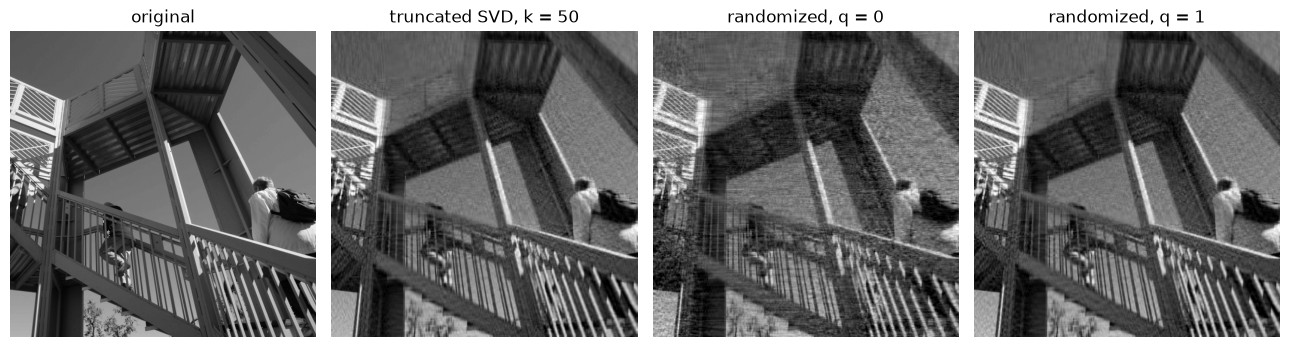

In [11]:
img = np.load(data_file("ascent.npz"))["image"].astype(float)
print("image shape", img.shape, "gray levels", img.min(), "to", img.max())

U_full, s_full, Vt_full = np.linalg.svd(img)
k = 50
opt2, optF = optimal_errors(s_full, k)
print(f"sigma_1 = {s_full[0]:.1f}, sigma_51 = {s_full[k]:.1f}, "
      f"relative optimal Frobenius error at k = {k}: {optF / np.linalg.norm(s_full):.4f}")

rows = []
approx = {}
for q in (0, 1, 2):
    U, s, Vt = randomized_svd(img, k, p=10, q=q, rng=rng)
    approx[q] = (U * s) @ Vt
    e2 = np.linalg.norm(img - approx[q], 2)
    eF = np.linalg.norm(img - approx[q], "fro")
    rows.append((q, e2 / opt2, eF / optF))
    assert e2 >= opt2 * (1 - 1e-12) and eF >= optF * (1 - 1e-12)
for q, r2, rF in rows:
    print(f"q = {q}: 2-norm error / optimal = {r2:.3f}, Frobenius error / optimal = {rF:.3f}")

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
panels = [("original", img), (f"truncated SVD, k = {k}", (U_full[:, :k] * s_full[:k]) @ Vt_full[:k]),
          (f"randomized, q = 0", approx[0]), (f"randomized, q = 1", approx[1])]
for ax, (title, M) in zip(axes, panels):
    ax.imshow(np.clip(M, 0, 255), cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

The singular values of a photograph decay slowly after the first few, so
without power iterations the randomized approximation has a noticeably
larger error than the optimal one (see the printed ratios, especially in the
2-norm); one or two power iterations bring it close to optimal.

**Timing.** We time the full SVD (singular vectors included, as needed for the
truncation), the SVD without vectors, and the randomized SVD with
$q = 0, 1, 2$.
The flop counts are $\mathcal{O}(n^3)$ for the dense SVD and about
$4(q+1)n^2\ell$ for the randomized SVD. The measured times are observations on
the machine that ran this notebook; for a matrix this small, fixed
overheads and the efficiency of the LAPACK implementation matter as much as
the flop counts.

In [12]:
t_full = median_time(lambda: np.linalg.svd(img, full_matrices=False))
t_vals = median_time(lambda: np.linalg.svd(img, compute_uv=False))
t_rand = {q: median_time(lambda q=q: randomized_svd(img, k, p=10, q=q, rng=rng)) for q in (0, 1, 2)}
print(f"full SVD (with vectors):     {t_full * 1e3:7.1f} ms")
print(f"singular values only:        {t_vals * 1e3:7.1f} ms")
for q, t in t_rand.items():
    print(f"randomized SVD, k = {k}, q = {q}: {t * 1e3:7.1f} ms   (flops about {4 * (q + 1) * 512**2 * (k + 10) / 1e6:.0f} M)")

full SVD (with vectors):       131.4 ms
singular values only:           34.9 ms
randomized SVD, k = 50, q = 0:     9.0 ms   (flops about 63 M)
randomized SVD, k = 50, q = 1:    14.2 ms   (flops about 126 M)
randomized SVD, k = 50, q = 2:    56.9 ms   (flops about 189 M)


Compare the printed times with the flop counts. The dense SVD of a
$512\times512$ matrix costs a few times $512^3\approx1.3\times10^8$ flops, so
the flop ratio is modest, and the observed ratio need not follow it: the
dense SVD is a single call to a highly optimized LAPACK routine, whereas our
randomized SVD performs several separate calls from Python, each with its own
overhead. The advantage of randomization
grows with the size of the matrix, and becomes decisive when the matrix is so
large that each pass over it is expensive.

## 8. Random embeddings: the Johnson--Lindenstrauss phenomenon

We take $N = 200$ points in $\mathbb{R}^{d}$, $d = 5000$, and map them with
$S = G/\sqrt{k}$, $G$ a $k\times d$ Gaussian matrix. For every pair we compute
the distortion $\|Sx_i - Sx_j\|_2^2/\|x_i - x_j\|_2^2 - 1$. The Gaussian
version of the Johnson--Lindenstrauss lemma ([Theorem 12.3](https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html#ch12-thm-jl-gaussian))
guarantees distortion at most $\varepsilon$ for all pairs, with probability
at least $1-\delta$, when $k\ge 12(2\ln N + \ln(1/\delta))/(\varepsilon^2(3-2\varepsilon))$.

k =    25: max distortion 1.176, 99th percentile 0.695, theorem (delta = 0.01) guarantees none (eps would exceed 1)
k =    50: max distortion 0.950, 99th percentile 0.494, theorem (delta = 0.01) guarantees none (eps would exceed 1)
k =   100: max distortion 0.549, 99th percentile 0.377, theorem (delta = 0.01) guarantees none (eps would exceed 1)
k =   200: max distortion 0.336, 99th percentile 0.224, theorem (delta = 0.01) guarantees 0.817
k =   400: max distortion 0.297, 99th percentile 0.174, theorem (delta = 0.01) guarantees 0.471
k =   800: max distortion 0.169, 99th percentile 0.124, theorem (delta = 0.01) guarantees 0.309


k =  1600: max distortion 0.156, 99th percentile 0.091, theorem (delta = 0.01) guarantees 0.210


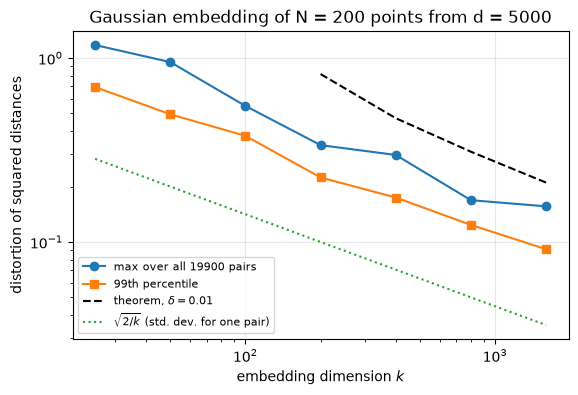

In [13]:
N, d = 200, 5000
X = rng.standard_normal((N, d)) * rng.exponential(1.0, size=(N, 1))  # points at various scales
X[:20] += 5 * rng.standard_normal((1, d))                              # and a cluster
D2 = pdist(X, "sqeuclidean")


def jl_epsilon(k, N, delta):
    """Smallest eps in (0,1) with k >= 12 (2 ln N + ln(1/delta)) / (eps^2 (3 - 2 eps)), or nan."""
    target = 12 * (2 * np.log(N) + np.log(1 / delta)) / k
    grid = np.linspace(1e-4, 0.9999, 100_000)
    ok = grid**2 * (3 - 2 * grid) >= target
    return grid[ok][0] if ok.any() else np.nan


ks_jl = [25, 50, 100, 200, 400, 800, 1600]
max_dist, q99 = [], []
for k in ks_jl:
    S = rng.standard_normal((k, d)) / np.sqrt(k)
    ratio = pdist(X @ S.T, "sqeuclidean") / D2 - 1
    max_dist.append(np.max(np.abs(ratio)))
    q99.append(np.quantile(np.abs(ratio), 0.99))
    eps_bound = jl_epsilon(k, N, 0.01)
    if not np.isnan(eps_bound):
        # The theorem guarantees this with probability at least 0.99 (the seed is fixed).
        assert max_dist[-1] <= eps_bound
    guarantee = "none (eps would exceed 1)" if np.isnan(eps_bound) else f"{eps_bound:.3f}"
    print(f"k = {k:5d}: max distortion {max_dist[-1]:.3f}, 99th percentile {q99[-1]:.3f}, "
          f"theorem (delta = 0.01) guarantees {guarantee}")

fig, ax = plt.subplots()
ax.loglog(ks_jl, max_dist, "o-", label="max over all 19900 pairs")
ax.loglog(ks_jl, q99, "s-", label="99th percentile")
ax.loglog(ks_jl, [jl_epsilon(k, N, 0.01) for k in ks_jl], "k--", label=r"theorem, $\delta = 0.01$")
ax.loglog(ks_jl, np.sqrt(2 / np.array(ks_jl)), ":", label=r"$\sqrt{2/k}$ (std. dev. for one pair)")
ax.set_xlabel("embedding dimension $k$")
ax.set_ylabel("distortion of squared distances")
ax.set_title(f"Gaussian embedding of N = {N} points from d = {d}")
ax.legend(fontsize=8)
plt.show()

**Interpretation.** The distortion decreases like $k^{-1/2}$; by the theory it
does not depend on $d$ or on how the points are arranged. The maximum over the 19,900 pairs
is a few times the standard deviation $\sqrt{2/k}$ of a single pair, and the
theorem's guarantee (which comes from a union bound) is only moderately
pessimistic. To halve the distortion one must quadruple $k$: random
embeddings are cheap to make accurate to 10 percent and expensive to make
accurate to 1 percent.

**Subspace embeddings.** For a whole $n$-dimensional subspace with
orthonormal basis $U$, the distortion is determined by the extreme singular
values of $SU$, which is itself an $s\times n$ Gaussian matrix divided by
$\sqrt{s}$ ([Lemma 12.1](https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html#ch12-lem-rotation)). They cluster near
$1\pm\sqrt{n/s}$.

In [14]:
m, n_sub = 5000, 50
U_sub, _ = np.linalg.qr(rng.standard_normal((m, n_sub)))
print("   s    sigma_min(SU)  1-sqrt(n/s)   sigma_max(SU)  1+sqrt(n/s)")
for s in (100, 200, 400, 800, 1600):
    sv = np.linalg.svd(rng.standard_normal((s, m)) @ U_sub / np.sqrt(s), compute_uv=False)
    print(f"{s:5d}   {sv[-1]:12.3f}  {1 - np.sqrt(n_sub / s):11.3f}   {sv[0]:12.3f}  {1 + np.sqrt(n_sub / s):11.3f}")

   s    sigma_min(SU)  1-sqrt(n/s)   sigma_max(SU)  1+sqrt(n/s)
  100          0.316        0.293          1.692        1.707
  200          0.504        0.500          1.445        1.500


  400          0.657        0.646          1.314        1.354
  800          0.754        0.750          1.242        1.250
 1600          0.835        0.823          1.163        1.177


## 9. Sketch-and-solve least squares

We now solve a tall least-squares problem, $m = 4000$, $n = 50$, with
$\kappa_2(A) = 10^6$. We construct $b = Ax_\star + r_\star$ with $r_\star$
orthogonal to $\operatorname{range}(A)$ and $\|r_\star\|_2 = \tfrac12\|Ax_\star\|_2$,
so that the exact solution $x_\star$ is known and the residual is not small.
Sketch-and-solve replaces $\min\|Ax-b\|_2$ by $\min\|S(Ax-b)\|_2$ for an $s\times m$ Gaussian
$S$. Two results from the notes can be tested:

- [Theorem 12.7](https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html#ch12-thm-sketch-solve) is deterministic: if $S$ is an
  $\varepsilon$-subspace embedding for $\operatorname{range}([A,\,b])$, then
  $\|A\tilde x - b\|_2\le\sqrt{(1+\varepsilon)/(1-\varepsilon)}\,\|Ax_\star - b\|_2$.
  We compute $\varepsilon$ for each sketch from the singular values of
  $S[A,\,b]$'s orthonormalized version and assert the inequality.
- [Proposition 12.5](https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html#ch12-prop-gaussian-sketch-solve) gives the expectation exactly:
  $\mathbb{E}\|A\tilde x - b\|_2^2 = (1 + n/(s-n-1))\|Ax_\star - b\|_2^2$.

s =    60: mean ||A x_sk - b||^2 / ||A x_* - b||^2 = 5.045, expectation 1 + n/(s-n-1) = 6.556
s =    75: mean ||A x_sk - b||^2 / ||A x_* - b||^2 = 3.205, expectation 1 + n/(s-n-1) = 3.083


s =   100: mean ||A x_sk - b||^2 / ||A x_* - b||^2 = 2.032, expectation 1 + n/(s-n-1) = 2.020


s =   150: mean ||A x_sk - b||^2 / ||A x_* - b||^2 = 1.497, expectation 1 + n/(s-n-1) = 1.505


s =   200: mean ||A x_sk - b||^2 / ||A x_* - b||^2 = 1.351, expectation 1 + n/(s-n-1) = 1.336


s =   400: mean ||A x_sk - b||^2 / ||A x_* - b||^2 = 1.155, expectation 1 + n/(s-n-1) = 1.143


s =   800: mean ||A x_sk - b||^2 / ||A x_* - b||^2 = 1.068, expectation 1 + n/(s-n-1) = 1.067


s =  1600: mean ||A x_sk - b||^2 / ||A x_* - b||^2 = 1.032, expectation 1 + n/(s-n-1) = 1.032


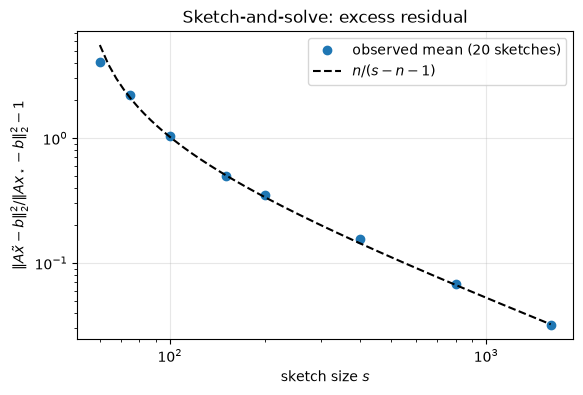

In [15]:
m, n_ls = 4000, 50
U_ls, _ = np.linalg.qr(rng.standard_normal((m, n_ls)))
A_ls = (U_ls * np.logspace(0, -6, n_ls)) @ haar_orthogonal(n_ls, rng).T
x_true = rng.standard_normal(n_ls)
r_true = rng.standard_normal(m)
r_true -= U_ls @ (U_ls.T @ r_true)                            # orthogonal to range(A) ...
r_true *= 0.5 * np.linalg.norm(A_ls @ x_true) / np.linalg.norm(r_true)
b_ls = A_ls @ x_true + r_true                                # ... so x_true is the exact LS solution

Qa, Ra = np.linalg.qr(A_ls)                                  # Householder QR: the reference solver
x_qr = sla.solve_triangular(Ra, Qa.T @ b_ls)
r_opt = np.linalg.norm(A_ls @ x_qr - b_ls)
Uab, _ = np.linalg.qr(np.column_stack([A_ls, b_ls]))         # orthonormal basis of range([A, b])

sizes = [60, 75, 100, 150, 200, 400, 800, 1600]
mean_sq = []
for s in sizes:
    vals = []
    for _ in range(20):
        S = rng.standard_normal((s, m)) / np.sqrt(s)
        x_sk, *_ = np.linalg.lstsq(S @ A_ls, S @ b_ls, rcond=None)
        ratio = np.linalg.norm(A_ls @ x_sk - b_ls) / r_opt
        vals.append(ratio**2)
        sv = np.linalg.svd(S @ Uab, compute_uv=False)
        eps = max(sv[0] ** 2 - 1, 1 - sv[-1] ** 2)
        if eps < 1:                                          # S is an eps-subspace embedding
            assert ratio <= np.sqrt((1 + eps) / (1 - eps)) * (1 + 1e-8)   # deterministic theorem
    mean_sq.append(np.mean(vals))
    print(f"s = {s:5d}: mean ||A x_sk - b||^2 / ||A x_* - b||^2 = {mean_sq[-1]:.3f}, "
          f"expectation 1 + n/(s-n-1) = {1 + n_ls / (s - n_ls - 1):.3f}")

fig, ax = plt.subplots()
ax.loglog(sizes, np.array(mean_sq) - 1, "o", label="observed mean (20 sketches)")
sg = np.linspace(sizes[0], sizes[-1], 400)
ax.loglog(sg, n_ls / (sg - n_ls - 1), "k--", label=r"$n/(s-n-1)$")
ax.set_xlabel("sketch size $s$")
ax.set_ylabel(r"$\|A\tilde x - b\|_2^2/\|Ax_\star - b\|_2^2 - 1$")
ax.set_title("Sketch-and-solve: excess residual")
ax.legend()
plt.show()

The excess residual follows $n/(s-n-1)$ closely. Reaching a residual within
1 percent of optimal (squared ratio $1.02$) would need $s\approx 50n$, and
the *solution* is much less accurate than the residual suggests, as the
next cell shows.

In [16]:
S = rng.standard_normal((400, m)) / np.sqrt(400)
x_sk, *_ = np.linalg.lstsq(S @ A_ls, S @ b_ls, rcond=None)
print(f"relative forward error, Householder QR:          {np.linalg.norm(x_qr - x_true) / np.linalg.norm(x_true):.1e}")
print(f"relative forward error, sketch-and-solve s = 400: {np.linalg.norm(x_sk - x_true) / np.linalg.norm(x_true):.1e}")
print(f"relative difference between the two solutions:   {np.linalg.norm(x_sk - x_qr) / np.linalg.norm(x_qr):.1e}")

relative forward error, Householder QR:          3.5e-07
relative forward error, sketch-and-solve s = 400: 4.2e+03
relative difference between the two solutions:   4.2e+03


## 10. Sketch-and-precondition

Now we use the sketch only to build a preconditioner: $SA = QR$, and LSQR
is applied to $\min_y\|AR^{-1}y - b\|_2$, $x = R^{-1}y$. By
[Theorem 12.8](https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html#ch12-thm-precondition), $\kappa_2(AR^{-1})$ is bounded in terms of
the embedding distortion alone, and for a Gaussian sketch it equals
$\kappa_2(SU)$ exactly, whatever $\kappa_2(A)$ is
([Proposition 12.6](https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html#ch12-prop-gaussian-precondition)).

In [17]:
def sketch_precondition_lstsq(A, b, s, rng, tol=1e-14, maxiter=500):
    """Gaussian sketch-and-precondition with LSQR (Blendenpik-style, but with a dense Gaussian sketch)."""
    m, n = A.shape
    S = rng.standard_normal((s, m)) / np.sqrt(s)
    Qs, R = np.linalg.qr(S @ A)
    x0 = sla.solve_triangular(R, Qs.T @ (S @ b))             # sketch-and-solve initial guess
    op = LinearOperator((m, n),
                        matvec=lambda y: A @ sla.solve_triangular(R, y),
                        rmatvec=lambda z: sla.solve_triangular(R, A.T @ z, trans="T"))
    y, istop, itn = lsqr(op, b - A @ x0, atol=tol, btol=tol, iter_lim=maxiter)[:3]
    return x0 + sla.solve_triangular(R, y), R, itn


print(f"kappa_2(A) = {np.linalg.cond(A_ls):.2e}")
print("   s    kappa(A R^-1)   kappa(S U)   LSQR iterations   forward error")
for s in (75, 100, 200, 400):
    state = rng.bit_generator.state                          # replay the same sketch to compare
    x_sp, R, itn = sketch_precondition_lstsq(A_ls, b_ls, s, rng)
    rng.bit_generator.state = state
    S = rng.standard_normal((s, m)) / np.sqrt(s)
    kap_AR = np.linalg.cond(sla.solve_triangular(R, A_ls.T, trans="T").T)
    kap_SU = np.linalg.cond(S @ U_ls)
    fwd = np.linalg.norm(x_sp - x_true) / np.linalg.norm(x_true)
    print(f"{s:5d}   {kap_AR:12.3f}   {kap_SU:10.3f}   {itn:15d}   {fwd:.1e}")
    sv = np.linalg.svd(S @ U_ls, compute_uv=False)
    eps = max(sv[0] ** 2 - 1, 1 - sv[-1] ** 2)
    if eps < 1:
        assert kap_AR <= np.sqrt((1 + eps) / (1 - eps)) * (1 + 1e-6)
    # kappa(A R^-1) = kappa(S U) in exact arithmetic; computing A R^-1 with kappa(A) = 1e6 costs
    # a relative perturbation of order kappa(A) u = 1e-10 in its singular values.
    assert abs(kap_AR - kap_SU) <= 1e-6 * kap_SU

kappa_2(A) = 1.00e+06
   s    kappa(A R^-1)   kappa(S U)   LSQR iterations   forward error


   75          8.359        8.359                64   9.1e-07
  100          5.245        5.245                49   5.0e-06
  200          2.890        2.890                34   2.8e-06
  400          1.945        1.945                24   1.9e-06


The condition number of the preconditioned matrix is small and matches
$\kappa_2(SU)$ to many digits, although $\kappa_2(A) = 10^6$. The number of
LSQR iterations needed to reach the tolerance $10^{-14}$ drops as $s$ grows,
in line with the convergence factor $(\kappa-1)/(\kappa+1)$ of
[(12.10)](https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html#equation-ch12-eq-lsqr-rate). Without the preconditioner, LSQR makes little
progress in the same number of iterations:

In [18]:
for iters in (50, 500):
    x_plain = lsqr(A_ls, b_ls, atol=1e-14, btol=1e-14, iter_lim=iters)[0]
    print(f"unpreconditioned LSQR, {iters:3d} iterations: relative forward error "
          f"{np.linalg.norm(x_plain - x_true) / np.linalg.norm(x_true):.1e}")

unpreconditioned LSQR,  50 iterations: relative forward error 7.5e-01


unpreconditioned LSQR, 500 iterations: relative forward error 3.1e-01


**Accuracy.** How accurate is the preconditioned solution compared with a
direct solver? For a backward stable least-squares method, the relative
forward error is bounded by roughly
$\kappa_2(A)u + \kappa_2(A)^2u\,\|r_\star\|_2/(\|A\|_2\|x_\star\|_2)$
([Chapter 8](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08)). We compare Householder QR, `np.linalg.lstsq`
(an SVD-based LAPACK solver), sketch-and-solve and sketch-and-precondition
on the same problem, repeating the randomized solvers with five sketches.

In [19]:
kappa_A = np.linalg.cond(A_ls)
sens = kappa_A * u + kappa_A**2 * u * np.linalg.norm(r_true) / (np.linalg.norm(A_ls, 2) * np.linalg.norm(x_true))


def fwd(x):
    return np.linalg.norm(x - x_true) / np.linalg.norm(x_true)


x_lapack, *_ = np.linalg.lstsq(A_ls, b_ls, rcond=None)
print(f"sensitivity level kappa u + kappa^2 u ||r||/(||A|| ||x||) = {sens:.1e}")
print(f"Householder QR:            forward error {fwd(x_qr):.1e}")
print(f"np.linalg.lstsq (SVD):     forward error {fwd(x_lapack):.1e}")
errs_ss, errs_sp = [], []
for _ in range(5):
    S = rng.standard_normal((400, m)) / np.sqrt(400)
    errs_ss.append(fwd(np.linalg.lstsq(S @ A_ls, S @ b_ls, rcond=None)[0]))
    errs_sp.append(fwd(sketch_precondition_lstsq(A_ls, b_ls, 400, rng)[0]))
print("sketch-and-solve, s = 400: forward errors", np.array(errs_ss).round(3))
print("sketch-and-precondition:   forward errors", np.array(errs_sp))
assert max(errs_sp) < 10 * sens            # at the level of the problem's sensitivity
assert fwd(x_qr) < 10 * sens and fwd(x_lapack) < 10 * sens
assert min(errs_ss) > 1e3 * sens           # sketch-and-solve is limited by the sketch, not by rounding

sensitivity level kappa u + kappa^2 u ||r||/(||A|| ||x||) = 1.4e-05
Householder QR:            forward error 3.5e-07
np.linalg.lstsq (SVD):     forward error 3.5e-07


sketch-and-solve, s = 400: forward errors [11705.699  8420.868  7510.934  5793.156  3580.916]
sketch-and-precondition:   forward errors [8.89753817e-07 1.84457844e-06 2.74852268e-06 5.47719608e-07
 2.20796599e-06]


**Interpretation.** Sketch-and-solve gives a residual within a modest factor
of optimal, but because $\kappa_2(A)$ is large the corresponding solution is
completely wrong: by [Theorem 12.7](https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html#ch12-thm-sketch-solve),
$\|A(\tilde x - x_\star)\|_2\le\sqrt{2\varepsilon/(1-\varepsilon)}\,\|r_\star\|_2$, and
dividing by $\sigma_{\min}(A) = 10^{-6}$ allows a huge error in $x$.
Sketch-and-precondition, on the other hand, delivers a forward error below
the sensitivity level set by the conditioning of the problem, as the direct
solvers do. Compare the printed values: the direct solvers are somewhat more
accurate on this problem, which is consistent with the remark in the notes
that the floating-point behavior of sketch-and-precondition is more delicate
than that of Householder QR. Note that with a *Gaussian* sketch, forming $SA$ costs $2smn$ flops,
more than the $2mn^2$ of Householder QR; the method pays off only with fast
sketches (subsampled trigonometric transforms or sparse sign matrices), as in
Blendenpik.

## 11. Randomized trace estimation

The Girard--Hutchinson estimator
$\operatorname{tr}(A)\approx\frac1r\sum_{i=1}^r\omega_i^TA\omega_i$ needs only
products with $A$. For Gaussian $\omega_i$ and symmetric $A$ it is unbiased
with variance $2\|A\|_F^2/r$ ([Proposition 12.7](https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html#ch12-prop-hutchinson)). We test it on
a symmetric positive semidefinite matrix accessed only through products.

In [20]:
nt = 500
Ut = haar_orthogonal(nt, rng)
lam = 1.0 / np.arange(1, nt + 1)                   # eigenvalues 1, 1/2, ..., 1/500
At = (Ut * lam) @ Ut.T
tr_exact = lam.sum()
for r_samples in (10, 100, 1000):
    ests = []
    for _ in range(200):
        Om = rng.standard_normal((nt, r_samples))
        ests.append(np.sum(Om * (At @ Om)) / r_samples)
    ests = np.array(ests)
    pred_std = np.sqrt(2 / r_samples) * np.linalg.norm(lam)
    print(f"r = {r_samples:4d}: mean of 200 estimates {ests.mean():.3f} (exact {tr_exact:.3f}), "
          f"std {ests.std():.3f}, predicted std sqrt(2/r)||A||_F = {pred_std:.3f}")
    # The mean of 200 estimates has standard deviation pred_std/sqrt(200); allow 5 of those.
    assert abs(ests.mean() - tr_exact) < 5 * pred_std / np.sqrt(200)

r =   10: mean of 200 estimates 6.836 (exact 6.793), std 0.566, predicted std sqrt(2/r)||A||_F = 0.573


r =  100: mean of 200 estimates 6.789 (exact 6.793), std 0.194, predicted std sqrt(2/r)||A||_F = 0.181

r = 1000: mean of 200 estimates 6.792 (exact 6.793), std 0.055, predicted std sqrt(2/r)||A||_F = 0.057


The estimator is unbiased, and its standard deviation matches
$\sqrt{2/r}\,\|A\|_F$. Its error decreases only like $r^{-1/2}$: Monte Carlo
estimators give a few correct digits cheaply and many digits very
expensively.

## Common mistakes

- Omitting oversampling ($p = 0$). With $\ell = k$ the expected error bound
  is infinite for Gaussian test matrices, and in practice the error varies
  much more from run to run.
- Forming $(AA^T)^qA\Omega$ without orthonormalizing between products
  (Section 5). All directions with $\sigma_j/\sigma_1\lesssim u^{1/(2q+1)}$ are
  lost.
- Comparing the rank-$(k+p)$ approximation $QQ^TA$ with the rank-$k$ optimum
  and concluding that the randomized method "beats" the SVD. Truncate to
  rank $k$ before comparing.
- Judging a randomized method from one run. Report the distribution (or at
  least the mean and the worst case) over several seeds, and fix the seed for
  reproducibility.
- Using sketch-and-solve when an accurate solution $x$ is needed. It controls
  the residual, not the forward error.
- Using a dense Gaussian sketch for least squares and expecting a speedup
  over QR: forming $SA$ costs as much as the factorization.
- Using `np.random.seed`; pass a `Generator` from `np.random.default_rng`
  to every randomized function instead.

## Your turn

1. Replace the Gaussian test matrix in `range_finder` by a *sparse sign*
   matrix with $\zeta = 8$ nonzeros $\pm1/\sqrt{\zeta}$ per row of $\Omega$ at
   random positions (use `scipy.sparse`). Repeat the experiment of Section 4.
   Is the error distribution noticeably different?
2. Implement a single-pass variant: draw $\Omega$ and a second test matrix
   $\Psi$, compute $Y = A\Omega$ and $W = \Psi^TA$ in one pass, and recover
   $B\approx(\Psi^TQ)^{\dagger}W$. Compare its error with the two-pass
   randomized SVD on the "slow" matrix.
3. Use `randomized_svd` on the operator $A = L^{-1}$, where $L$ is the
   $n\times n$ second-difference matrix, applying $L^{-1}$ and $L^{-T}$
   only through sparse solves. How many power iterations are needed for a
   rank-10 approximation within 1 percent of optimal?
4. Repeat Section 10 with $s = 1.2n$ and with $s = 10n$ and plot the
   residual history of LSQR against the bound $2((\kappa-1)/(\kappa+1))^j$.

## Key takeaways

- The randomized range finder needs only products with $A$ and $A^T$; with
  oversampling $p = 5$ to $10$ its expected error is within a small factor
  of the Eckart--Young optimum, and it is exact for matrices of rank at most
  $k + p$.
- Slowly decaying singular values call for power iterations, which must
  re-orthonormalize after every product.
- The error can be estimated a posteriori from a few extra random samples,
  which makes adaptive choices of the rank possible.
- Random embeddings preserve distances of finite point sets and whole
  subspaces up to a distortion that scales like the square root of
  (dimension / sketch size).
- For least squares, sketching gives either a cheap approximate solution
  (sketch-and-solve, residual within a factor of optimal) or a preconditioner
  that makes an iterative solver converge in a number of iterations
  independent of $\kappa_2(A)$ (sketch-and-precondition).

## Further reading

Halko et al. (2011) (Sections 4, 5 and 10) for the range finder, power
iterations and their analysis; Martinsson and Tropp (2020) for a modern survey
including embeddings, trace estimation and least squares;
Woodruff (2014) for subspace embeddings; Avron et al. (2010) for
Blendenpik.